# 06 · Evaluación — Importancia de variables (comparación de los 3 modelos)

¿En qué variables se apoya cada modelo, y **coinciden** entre sí? Comparar la
importancia en XGBoost, Random Forest y LogReg sirve para dos cosas: ver si la señal
es **robusta** (las mismas variables mandan en familias de modelo distintas) y
sumar un criterio a la elección del modelo final (uno cuya señal sea interpretable y
coherente con el dominio es preferible aunque empate en métricas).

Cruzamos **dos lentes complementarias**, porque ninguna basta por sí sola:

## 1. Importancia nativa — cada modelo la define a su manera

No es comparable número a número entre familias, pero sí el *ranking* dentro de cada una:

- **XGBoost — `gain`**: mejora promedio en la pérdida que aporta cada *split* sobre
  la variable. Mide *cuánto ayuda a separar*.
- **Random Forest — reducción de impureza (Gini)**: cuánto baja la impureza, en
  promedio, en los splits sobre esa variable. Sesgada hacia variables continuas / de
  alta cardinalidad.
- **LogReg — `|coeficiente|`**: como el modelo entrena sobre variables
  **estandarizadas** (StandardScaler), la magnitud del coeficiente es comparable
  entre variables e indica peso lineal (el signo da la dirección — eso lo ve SHAP).

**Limitación común**: son importancias *del entrenamiento*, no de la generalización,
y se reparten de forma arbitraria entre variables correlacionadas (aquí hay mucha
correlación entre las ventanas RFM u3/u6/u12).

## 2. Importancia por permutación — model-agnostic, comparable entre modelos

Se mide sobre el **test OOT**: se baraja una variable y se observa **cuánto cae el
AUC**. Es la **misma vara para los tres** → permite contrastar en pie de igualdad qué
señal *generaliza* en cada modelo.

**Limitación**: ante dos variables muy correlacionadas, permutar una sola apenas
mueve el AUC (la otra la sustituye) → puede *subestimar* a ambas. Por eso la leemos
junto a la nativa, no en su lugar.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent

df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]


def _reconstruir(key):
    """Reentrena un modelo desde sus hiperparámetros (fallback si falta el .joblib)."""
    best = json.load(open(base / "05_modelling" / f"{key}_best_params.json"))["best_params"]
    if key == "xgboost":
        from xgboost import XGBClassifier
        spw = (y_train == 0).sum() / (y_train == 1).sum()
        m = XGBClassifier(**best, scale_pos_weight=spw, eval_metric="logloss",
                          tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
    elif key == "rf":
        from sklearn.ensemble import RandomForestClassifier
        m = RandomForestClassifier(**best, class_weight="balanced", n_jobs=-1,
                                   random_state=RANDOM_STATE)
    else:  # logreg: StandardScaler + LogisticRegression elasticnet (saga)
        from sklearn.pipeline import make_pipeline
        from sklearn.preprocessing import StandardScaler
        from sklearn.linear_model import LogisticRegression
        m = make_pipeline(
            StandardScaler(),
            LogisticRegression(**best, penalty="elasticnet", solver="saga",
                               class_weight="balanced", max_iter=1000,
                               random_state=RANDOM_STATE))
    m.fit(X_train, y_train)
    return m


# (etiqueta, archivo .joblib, key de params, color) — orden de presentación
SPECS = [("XGBoost",       "xgboost_tuned", "xgboost", "#4c72b0"),
         ("Random Forest", "rf_tuned",      "rf",      "#55a868"),
         ("LogReg",        "logreg_tuned",  "logreg",  "#c44e52")]
COLOR = {label: c for label, _, _, c in SPECS}
LABELS = [s[0] for s in SPECS]

# Modelos entrenados sobre el train OOT → importancia/permutación sobre el test OOT.
models = {}
for label, fname, key, _ in SPECS:
    fp = base / "models" / f"{fname}.joblib"
    models[label] = joblib.load(fp) if fp.exists() else _reconstruir(key)
    estado = "cargado" if fp.exists() else "reconstruido"
    print(f"{label:14s} {estado}")

print(f"\ntest OOT: {test_mask.sum():,} filas | prevalencia churn {y_test.mean():.3f}")

XGBoost        cargado
Random Forest  cargado
LogReg         cargado

test OOT: 803 filas | prevalencia churn 0.262


## A · Importancia nativa de cada modelo

`gain` (XGBoost), reducción de impureza (RF) y `|coef|` sobre features
estandarizadas (LogReg), cada una **normalizada a suma 1** para poder comparar el
*peso relativo* (no el valor absoluto, que no es comparable entre familias).

In [2]:
nat = pd.DataFrame(index=FEATS)

# XGBoost: gain (el booster omite features sin splits → se rellenan con 0)
gain = pd.Series(models["XGBoost"].get_booster().get_score(importance_type="gain"))
nat["XGBoost"] = gain.reindex(FEATS).fillna(0.0)

# Random Forest: reducción de impureza (Gini), ya suma 1
nat["Random Forest"] = pd.Series(models["Random Forest"].feature_importances_, index=FEATS)

# LogReg: |coeficiente| sobre features estandarizadas (Pipeline → último paso)
coef = np.abs(models["LogReg"][-1].coef_.ravel())
nat["LogReg"] = pd.Series(coef, index=FEATS)

# normalizar cada columna a suma 1 → pesos relativos comparables
nat = nat / nat.sum()

print("Importancia nativa normalizada (suma 1 por modelo). Top 15 por gain de XGBoost:")
print(nat.sort_values("XGBoost", ascending=False).head(15).round(4).to_string())

Importancia nativa normalizada (suma 1 por modelo). Top 15 por gain de XGBoost:
                           XGBoost  Random Forest  LogReg
n_prod_u12                  0.1672         0.1211  0.0000
monto_u6                    0.1218         0.1039  0.0025
n_ped_u6                    0.1157         0.0628  0.0043
n_ped_u12                   0.0954         0.0784  0.0043
n_ped_u3                    0.0389         0.0398  0.0000
monto_u3                    0.0361         0.0717  0.0349
n_ped_acum                  0.0298         0.0393  0.0110
n_prod_acum                 0.0255         0.0429  0.0342
compras_hist                0.0187         0.0240  0.1022
intensidad_u3               0.0150         0.0149  0.1261
meses_activos_u12           0.0130         0.0348  0.1104
meses_desde_compra_previa   0.0124         0.0097  0.0074
monto_mean_u12              0.0110         0.0398  0.0540
meses_activos_u3            0.0100         0.0058  0.0606
monto_cv_u12                0.0095         0.0249 

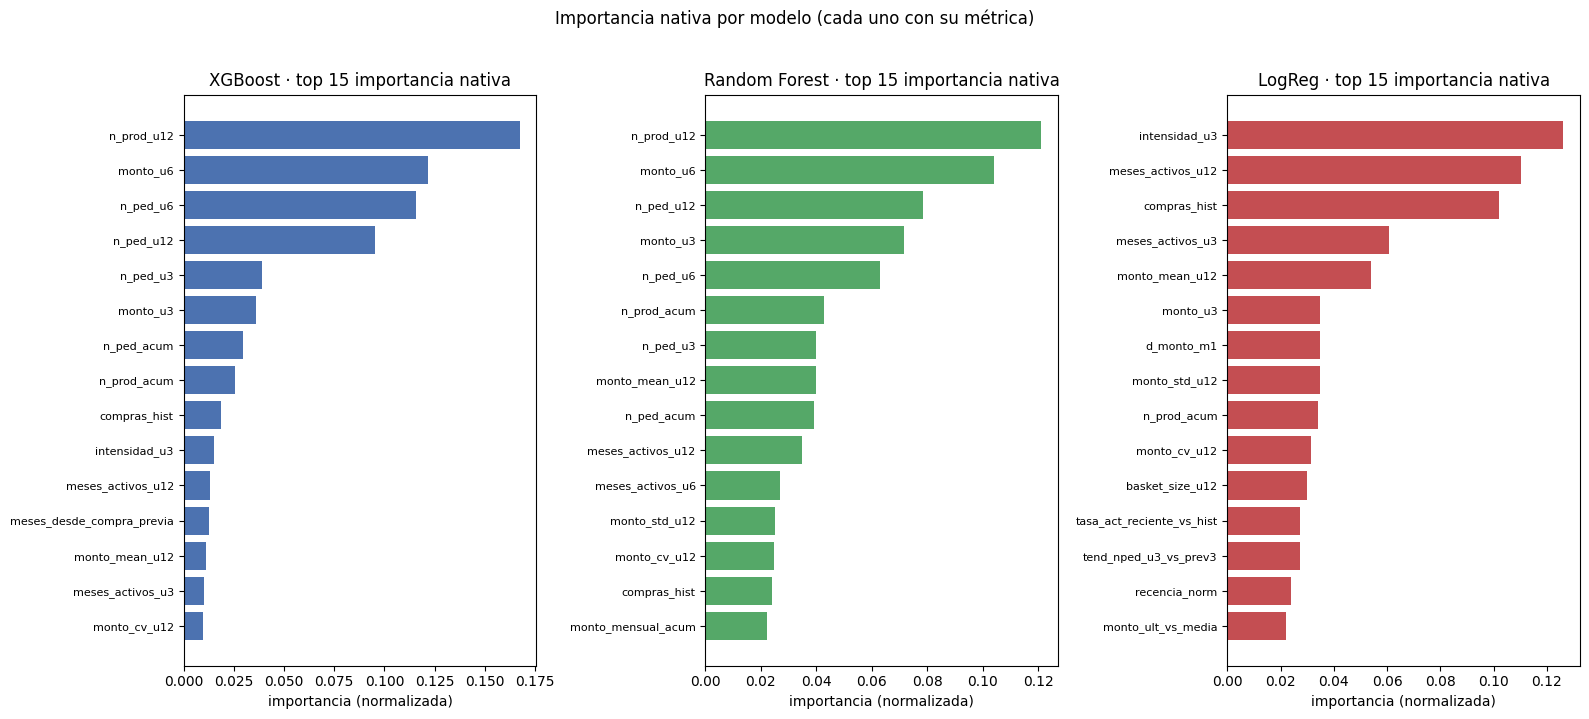

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, l in zip(axes, LABELS):
    top = nat[l].sort_values(ascending=False).head(15).iloc[::-1]
    ax.barh(top.index, top.values, color=COLOR[l])
    ax.set_title(f"{l} · top 15 importancia nativa")
    ax.set_xlabel("importancia (normalizada)")
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Importancia nativa por modelo (cada uno con su métrica)", y=1.02)
plt.tight_layout(); plt.show()

## B · Importancia por permutación (sobre el test OOT, los 3 modelos)

La **misma métrica para los tres**: caída de AUC al barajar cada variable. `n_repeats=10`
para tener media por variable. Al ser model-agnostic, las columnas **sí son
comparables** entre modelos — es la base de la sección C.

In [4]:
from sklearn.inspection import permutation_importance

perm_df = pd.DataFrame(index=FEATS)
for l in LABELS:
    r = permutation_importance(models[l], X_test, y_test, scoring="roc_auc",
                               n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
    perm_df[l] = pd.Series(r.importances_mean, index=FEATS)

print("Caída de AUC por permutación (test OOT). Top 15 por XGBoost:")
print(perm_df.sort_values("XGBoost", ascending=False).head(15).round(5).to_string())

Caída de AUC por permutación (test OOT). Top 15 por XGBoost:
                           XGBoost  Random Forest   LogReg
n_ped_u12                  0.00977        0.00485  0.00011
n_prod_u12                 0.00925        0.00405  0.00000
n_ped_u6                   0.00270        0.00176  0.00011
n_ped_u3                   0.00221        0.00226  0.00000
intensidad_u3              0.00134        0.00068  0.02785
meses_desde_compra_previa  0.00118        0.00098  0.00037
ticket_prom_u3             0.00109       -0.00031  0.00000
antiguedad_meses           0.00099       -0.00017  0.00000
meses_activos_u12          0.00080        0.00208  0.03594
departamento_la libertad   0.00078       -0.00000  0.00129
departamento_lima          0.00070        0.00008  0.00173
monto_cv_u12               0.00065        0.00153  0.00322
compras_hist               0.00063       -0.00192  0.04866
d_nped_m1                  0.00055        0.00020  0.00044
monto_std_u12              0.00050       -0.00047  0.0

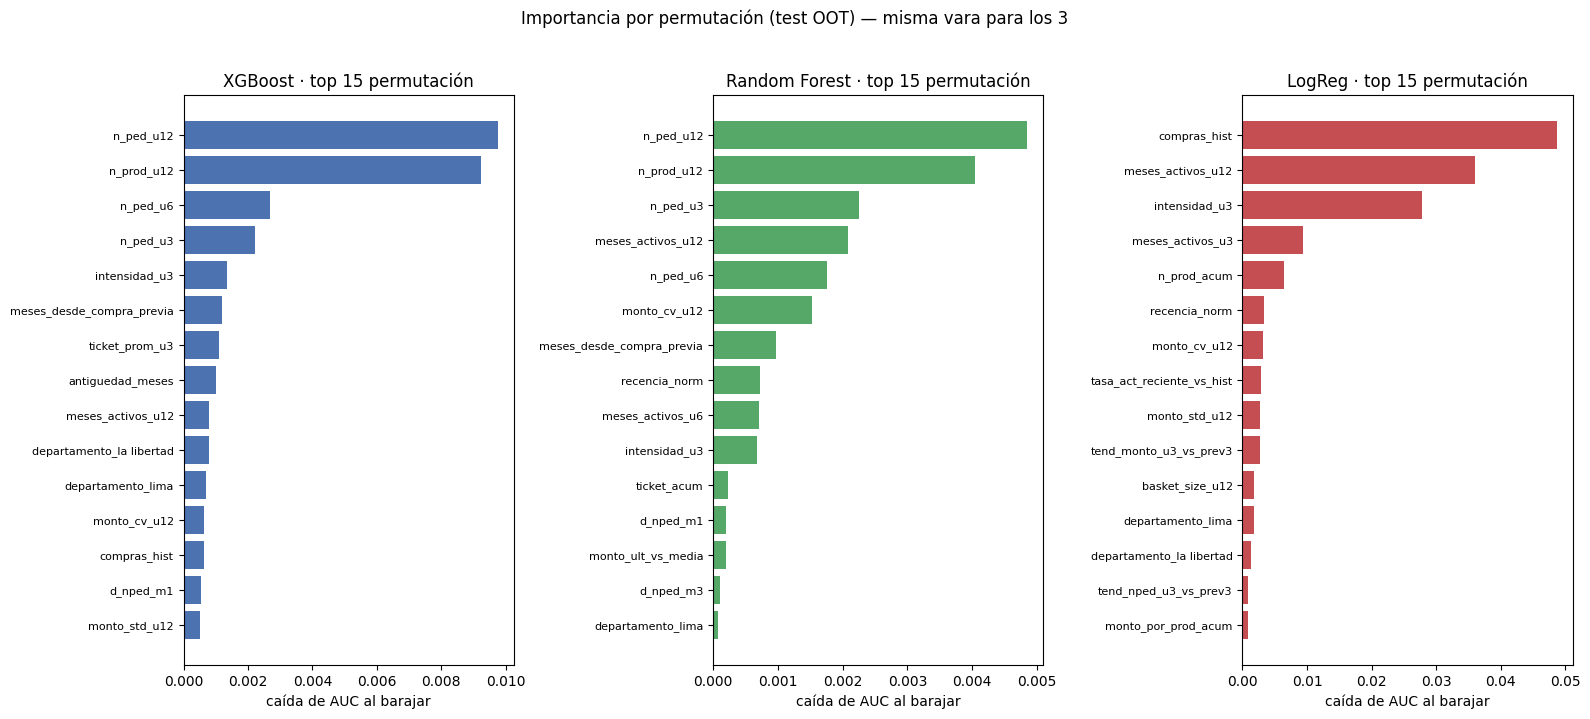

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, l in zip(axes, LABELS):
    top = perm_df[l].sort_values(ascending=False).head(15).iloc[::-1]
    ax.barh(top.index, top.values, color=COLOR[l])
    ax.set_title(f"{l} · top 15 permutación")
    ax.set_xlabel("caída de AUC al barajar")
    ax.axvline(0, color="k", lw=0.6)
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Importancia por permutación (test OOT) — misma vara para los 3", y=1.02)
plt.tight_layout(); plt.show()

## C · Acuerdo entre modelos

¿Los tres se apoyan en las **mismas** variables? Lo medimos sobre el ranking de
permutación (la lente comparable):

- **Correlación de Spearman** entre los rankings de cada par de modelos: cercano a 1
  = coinciden en qué variables importan; bajo = cada modelo extrae la señal distinto.
- **Tabla de rankings**: la unión de los top-10 de cada modelo, con su posición en
  los tres. Las variables que aparecen **arriba en los tres** son la señal robusta,
  independiente del modelo — la base más segura para explicar el churn a negocio.

In [6]:
from scipy.stats import spearmanr

# ranking por permutación en cada modelo (1 = más importante)
rank_perm = perm_df.rank(ascending=False).astype(int)

corr = pd.DataFrame(
    [[spearmanr(perm_df[a], perm_df[b]).statistic for b in LABELS] for a in LABELS],
    index=LABELS, columns=LABELS)
print("Spearman entre rankings de permutación (acuerdo entre modelos):")
print(corr.round(3).to_string())

top_union = sorted({f for l in LABELS
                    for f in perm_df[l].sort_values(ascending=False).head(10).index})
tabla = rank_perm.loc[top_union].copy()
tabla["rank_max"] = tabla.max(axis=1)          # peor posición entre los 3
print("\nRank por permutación en cada modelo (unión de los top-10). 1 = más importante:")
print(tabla.sort_values("rank_max").to_string())

Spearman entre rankings de permutación (acuerdo entre modelos):
               XGBoost  Random Forest  LogReg
XGBoost          1.000          0.414   0.390
Random Forest    0.414          1.000   0.141
LogReg           0.390          0.141   1.000

Rank por permutación en cada modelo (unión de los top-10). 1 = más importante:
                           XGBoost  Random Forest  LogReg  rank_max
meses_activos_u12                9              4       2         9
intensidad_u3                    5             10       3        10
monto_cv_u12                    12              6       7        12
recencia_norm                   18              8       6        18
meses_desde_compra_previa        6              7      20        20
n_ped_u6                         3              5      28        28
n_ped_u12                        1              1      29        29
departamento_la libertad        10             31      13        31
n_prod_u12                       2              2      39   

## D · Síntesis

El modelo final es **XGBoost** (elegido por Top Decil Lift en `03_utilidad_modelo`).
Esta sección verifica que su señal sea **interpretable y robusta**:

- **Núcleo de señal compartido**: pese a un acuerdo solo moderado en el ranking
  completo, las variables de **recencia** (`recencia_norm`,
  `meses_desde_compra_previa`), **intensidad reciente** (`intensidad_u3`,
  `monto_cv_u12`) y **actividad sostenida** (`meses_activos_u12`) aparecen arriba en
  los tres modelos. Ese núcleo, coherente con el dominio (una vendedora que dejó de
  comprar y bajó su intensidad está en riesgo), es la explicación más confiable.
- **Acuerdo entre modelos (Spearman sobre permutación)**: XGBoost–RF 0.41,
  XGBoost–LogReg 0.39, RF–LogReg 0.14. Es **moderado-bajo**: cada familia extrae la
  señal de forma distinta (los dos árboles se parecen más entre sí; el LogReg es el
  más diferente, como era de esperar de un modelo puramente lineal). El acuerdo no es
  alto, pero **sí en el núcleo de variables** de arriba — que es lo que importa.
- **De qué se agarra cada uno (importancia nativa)**: XGBoost y RF concentran el
  *gain*/impureza en conteos de **actividad reciente** (`n_prod_u12`, `n_ped_u6/u12`,
  `monto_u6`); el LogReg reparte su peso lineal hacia `compras_hist`, `intensidad_u3`
  y `meses_activos_u12`. Misma historia de fondo (RFM), distinto énfasis por la forma
  funcional de cada modelo.
- **Lectura para la elección**: XGBoost prioriza por variables coherentes con el
  negocio, no por artefactos → su señal es interpretable y defendible. No contradice
  la elección por TDL; la respalda.

**Siguiente**: `02_shap.ipynb` desagrega *en qué dirección* y *con qué forma* cada
variable empuja la predicción de XGBoost, y la contrasta con los otros dos modelos.